## ЛР 1.1. Статистические ряды распределения.

**Выполнили**: Павлова С.И., Ровнягина М.А., Котяева А.Р.

Исходные данные – статистика преступлений, совершенных в Москве в
2021 году, распределенных по возрасту преступников.

In [197]:
import pandas as pd
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")

### 1. Построить дискретный и интервальный ряд распределения, разбив статистическую совокупность на 7 групп с равными интервалами.

In [198]:
data = pd.read_table('./data/moscow.txt', header=None)[0]
N = len(data)

group_data = defaultdict(int)
for x in data:
    group_data[x] += 1

discrete = pd.DataFrame(group_data.items(), columns=['x', 'p'])
discrete['p'] /= N

print('Дискретный ряд')
discrete.head()

Дискретный ряд


,x,p
0,23,0.033032
1,32,0.024550
2,27,0.038954
3,26,0.030225
4,44,0.031829


In [199]:
ages = sorted(group_data.keys())
min_age, max_age = ages[0], ages[-1]

interval = []
for x_l in range(min_age, max_age + 1, 9):
    x_r = x_l + 8
    n = len(data[(x_l <= data) & (data <= x_r)])
    interval.append([x_l, x_r, n])

interval = pd.DataFrame(interval, columns=['x_l', 'x_r', 'n'])
interval['x_r'] = interval['x_r'] + 1
interval['x_middle'] = (interval['x_l'] + interval['x_r']) / 2
interval['S'] = interval['n'].cumsum()

print('Интервальный ряд\n')
interval

Интервальный ряд



,x_l,x_r,n,x_middle,S
0,14,23,4811,18.5,4811
1,23,32,9476,27.5,14287
2,32,41,7243,36.5,21530
3,41,50,7951,45.5,29481
4,50,59,1140,54.5,30621
5,59,68,1472,63.5,32093
6,68,77,330,72.5,32423


### 2. Для каждого ряда реализовать функции для определения следующих статистических характеристик: **средняя**, **дисперсия**, **среднее квадратическое отклонение**, **коэффициент вариации**, **мода** и ее **частота**, **медиана**, **максимальное** и **минимальное значение**, **размах**.

In [200]:
def discrete_expected_value(x, p):
    return sum(x * p)

def discrete_dispersion(x, p, E):
    diff = x - E
    return sum(diff ** 2 * p)

def discrete_standard_deviation(D):
    return D ** 0.5

def discrete_coefficient_of_variation(sigma, E):
    return sigma / E * 100

def discrete_mode(x, p):
    max_idx = p.argmax()
    return x[max_idx]

def discrete_median(data, N):
    odd = True if N % 2 else False
    if odd:
        mid_idx = N // 2
    else:
        mid_idx = N // 2 - 1

    sort_data = data.sort_values(ignore_index=True)
    
    if odd:
        median = sort_data[mid_idx]
    else:
        median = (sort_data[mid_idx] + sort_data[mid_idx + 1]) / 2
    return median

def discrete_max(x):
    return x.max()

def discrete_min(x):
    return x.min()

def discrete_range(max_age, min_age):
    return max_age - min_age


def print_result(E, D, sigma, V, Mo, Me, max_age, min_age, R):
    print(f"Математическое ожидание  = {E:.4f}")
    print(f"Дисперсия                = {D:.4f}")
    print(f"Стандартное отклонение   = {sigma:.4f}")
    print(f"Коэффициент вариации     = {V:.4f}%")
    print(f"Мода                     = {Mo:.4f}")
    print(f"Медиана                  = {Me:.4f}")
    print(f"Максимальное значение    = {max_age:.4f}")
    print(f"Минимальное значение     = {min_age:.4f}")  
    print(f"Размах                   = {R:.4f}")

In [201]:
x, p = discrete['x'], discrete['p']

E = discrete_expected_value(x, p)
D = discrete_dispersion(x, p, E)
sigma = discrete_standard_deviation(D)
V = discrete_coefficient_of_variation(sigma, E)
Mo = discrete_mode(x, p)
Me = discrete_median(data, N)
max_age = discrete_max(x)
min_age = discrete_min(x)
R = discrete_range(max_age, min_age)

print('Дискретный ряд\n')
print_result(E, D, sigma, V, Mo, Me, max_age, min_age, R)

Дискретный ряд

Математическое ожидание  = 35.3730
Дисперсия                = 144.9170
Стандартное отклонение   = 12.0381
Коэффициент вариации     = 34.0320%
Мода                     = 29.0000
Медиана                  = 34.0000
Максимальное значение    = 73.0000
Минимальное значение     = 14.0000
Размах                   = 59.0000


In [202]:
def interval_expected_value(interval, N):
    x_middle, n = interval['x_middle'], interval['n']
    return sum(x_middle * n) / N

def interval_dispersion(interval, E, N):
    x_middle, n = interval['x_middle'], interval['n']
    diff = x_middle - E
    return sum(diff ** 2 * n) / N

def interval_standard_deviation(D):
    return D ** 0.5

def interval_coefficient_of_variation(sigma, E):
    return sigma / E * 100

def interval_mode(interval):
    max_idx = interval['n'].argmax()
    x_l = interval.loc[max_idx, 'x_l']
    h = interval.loc[max_idx, 'x_r'] - x_l
    n_i = interval.loc[max_idx, 'n']
    n_im1 = interval.loc[max_idx - 1, 'n'] if max_idx > 0 else 0
    n_ip1 = interval.loc[max_idx + 1, 'n'] if max_idx < len(interval) - 1 else 0
    Mo = x_l + h * (n_i - n_im1) / ((n_i - n_im1) + (n_i - n_ip1))
    return Mo

def interval_median(interval, N):
    median_idx = interval[interval['S'] >= N / 2].index[0]
    x_l = interval.loc[median_idx, 'x_l']
    h = interval.loc[median_idx, 'x_r'] - x_l
    n_i = interval.loc[median_idx, 'n']
    S_im1 = interval.loc[median_idx - 1, 'S'] if median_idx > 0 else 0
    Me = x_l + h * (N / 2 - S_im1) / n_i
    return Me

def interval_max(interval):
    return interval['x_r'].max()

def interval_min(interval):
    return interval['x_l'].min() 

def interval_range(interval):
    return interval_max(interval) - interval_min(interval)

In [203]:
E = interval_expected_value(interval, N)
D = interval_dispersion(interval, E, N)
sigma = interval_standard_deviation(D)
V = interval_coefficient_of_variation(sigma, E)
Mo = interval_mode(interval)
Me = interval_median(interval, N)
max_age = interval_max(interval)
min_age = interval_min(interval)
R = interval_range(interval)

print('Интервальный ряд\n')
print_result(E, D, sigma, V, Mo, Me, max_age, min_age, R)

Интервальный ряд

Математическое ожидание  = 35.6309
Дисперсия                = 148.5362
Стандартное отклонение   = 12.1875
Коэффициент вариации     = 34.2050%
Мода                     = 29.0865
Медиана                  = 34.3913
Максимальное значение    = 77.0000
Минимальное значение     = 14.0000
Размах                   = 63.0000


### 3. Построить полигон и гистограмму частот.

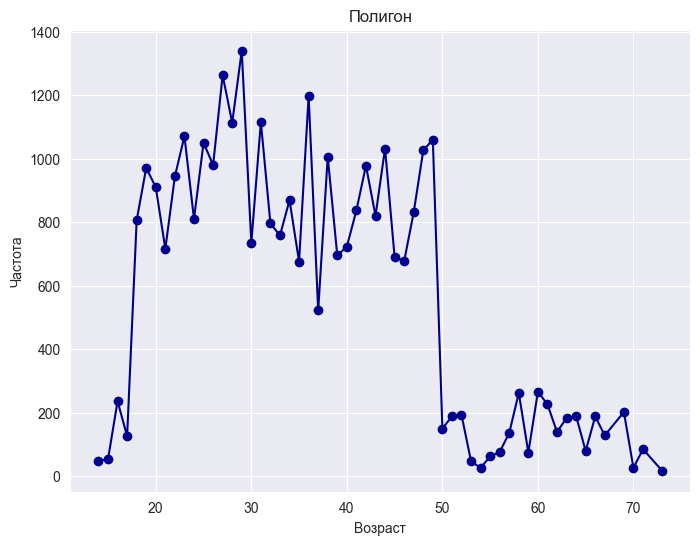

In [204]:
discrete.sort_values(by='x', inplace=True)
x, n = discrete['x'], discrete['p'] * N

plt.figure(figsize=(8,6))
plt.plot(x, n, marker='o', color='darkblue')
plt.title('Полигон')
plt.xlabel('Возраст')
plt.ylabel('Частота')
plt.show()

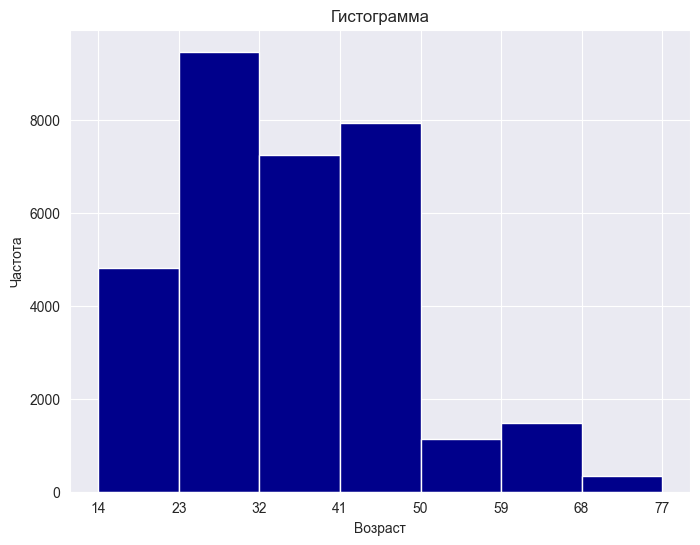

In [216]:
x_l, n = interval['x_l'], interval['n']
h = interval['x_r'] - x_l

plt.figure(figsize=(8,6))
plt.bar(x_l, n, color='darkblue', align='edge', width=h)
plt.title('Гистограмма')
plt.xlabel('Возраст')
plt.ylabel('Частота')
plt.xticks(pd.concat([x_l, pd.Series([77])]))
plt.show()